# ❤️ Task 3: Heart Disease Prediction
**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Build a binary classification model to predict whether a person is at risk of heart disease using health indicators.

## Dataset
**Heart Disease UCI Dataset** — from Kaggle (`ronitf/heart-disease-uci`)

**Target Column:** `target` — 1 = Heart Disease Present, 0 = No Heart Disease

In [1]:
# ─────────────────────────────────────────
# STEP 1: Install Libraries
# ─────────────────────────────────────────
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
print('✅ Libraries imported!')

✅ Libraries imported!


## 🔑 Kaggle API Setup & Dataset Download

In [11]:
# ─────────────────────────────────────────
# STEP 2: Upload & Configure Kaggle Token
# ─────────────────────────────────────────
from google.colab import files
import os

print('📤 Upload your kaggle.json file:')
uploaded = files.upload()

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('✅ Kaggle token configured successfully!')

📤 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle token configured successfully!


In [12]:
# ─────────────────────────────────────────
# STEP 3: Download Dataset from Kaggle
# ─────────────────────────────────────────
import os

os.makedirs('/content/heart_data/', exist_ok=True)
!kaggle datasets download -d cherngs/heart-disease-cleveland-uci --unzip -p /content/heart_data/

files_list = os.listdir('/content/heart_data/')
print('📁 Downloaded files:', files_list)

Dataset URL: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci
License(s): reddit-api
100% 3.33k/3.33k [00:00<00:00, 9.30MB/s]

📁 Downloaded files: ['heart_cleveland_upload.csv', 'heart.csv']


In [13]:
# ─────────────────────────────────────────
# STEP 4: Load Dataset
# ─────────────────────────────────────────
import os

# Pehle dekho konsi file download hui
print('Files:', os.listdir('/content/heart_data/'))

# Load karo
import pandas as pd
df = pd.read_csv('/content/heart_data/heart_cleveland_upload.csv')

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
display(df.head(10))

Files: ['heart_cleveland_upload.csv', 'heart.csv']
✅ Dataset loaded: 297 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


## 🔍 EDA & Preprocessing

In [16]:
# ─────────────────────────────────────────
# STEP 5: Data Inspection & Cleaning
# ─────────────────────────────────────────
print('📌 Column Info:')
df.info()

print('\n📌 Null Values:')
print(df.isnull().sum())

print('\n📌 Descriptive Statistics:')
display(df.describe().round(2))

# Target column dhundo automatically
target_col = 'target' if 'target' in df.columns else 'condition'
print(f'\n📌 Target column: {target_col}')
print(df[target_col].value_counts())

# Rename columns
col_map = {
    'age': 'Age', 'sex': 'Sex', 'cp': 'Chest Pain Type',
    'trestbps': 'Resting BP', 'chol': 'Cholesterol',
    'fbs': 'Fasting BS >120', 'restecg': 'Rest ECG',
    'thalach': 'Max Heart Rate', 'exang': 'Exercise Angina',
    'oldpeak': 'ST Depression', 'slope': 'ST Slope',
    'ca': 'Num Vessels', 'thal': 'Thalassemia',
    target_col: 'Target'
}
df.rename(columns=col_map, inplace=True)
print('\n✅ Columns renamed!')
print('Columns now:', df.columns.tolist())

📌 Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB

📌 Null Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca     

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,2.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,0.60,0.68,0.84,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,56.00,1.00,2.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,0.00,0.00
75%,61.00,1.00,3.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,2.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,2.00,1.00



📌 Target column: condition
condition
0    160
1    137
Name: count, dtype: int64

✅ Columns renamed!
Columns now: ['Age', 'Sex', 'Chest Pain Type', 'Resting BP', 'Cholesterol', 'Fasting BS >120', 'Rest ECG', 'Max Heart Rate', 'Exercise Angina', 'ST Depression', 'ST Slope', 'Num Vessels', 'Thalassemia', 'Target']


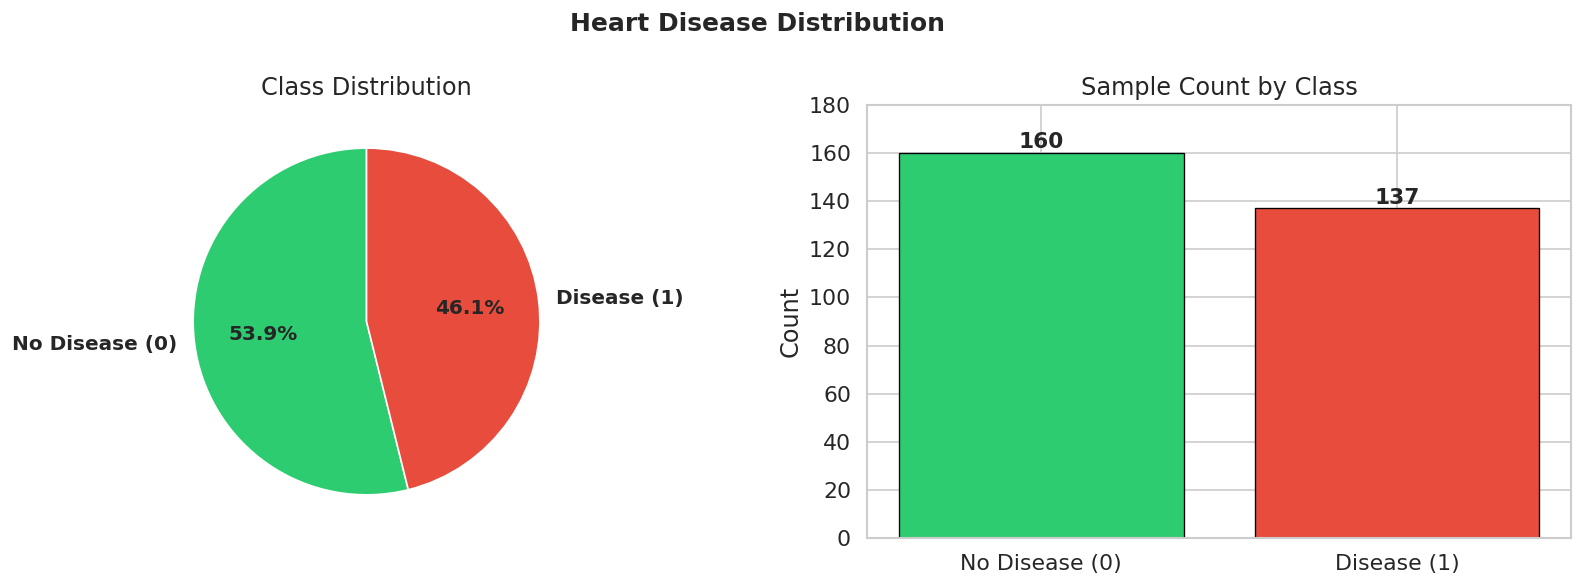

In [18]:
# ─────────────────────────────────────────
# STEP 6a: Target Distribution
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Heart Disease Distribution', fontsize=15, fontweight='bold')

counts = df['Target'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Class Distribution')

bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Sample Count by Class')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(counts)+20)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

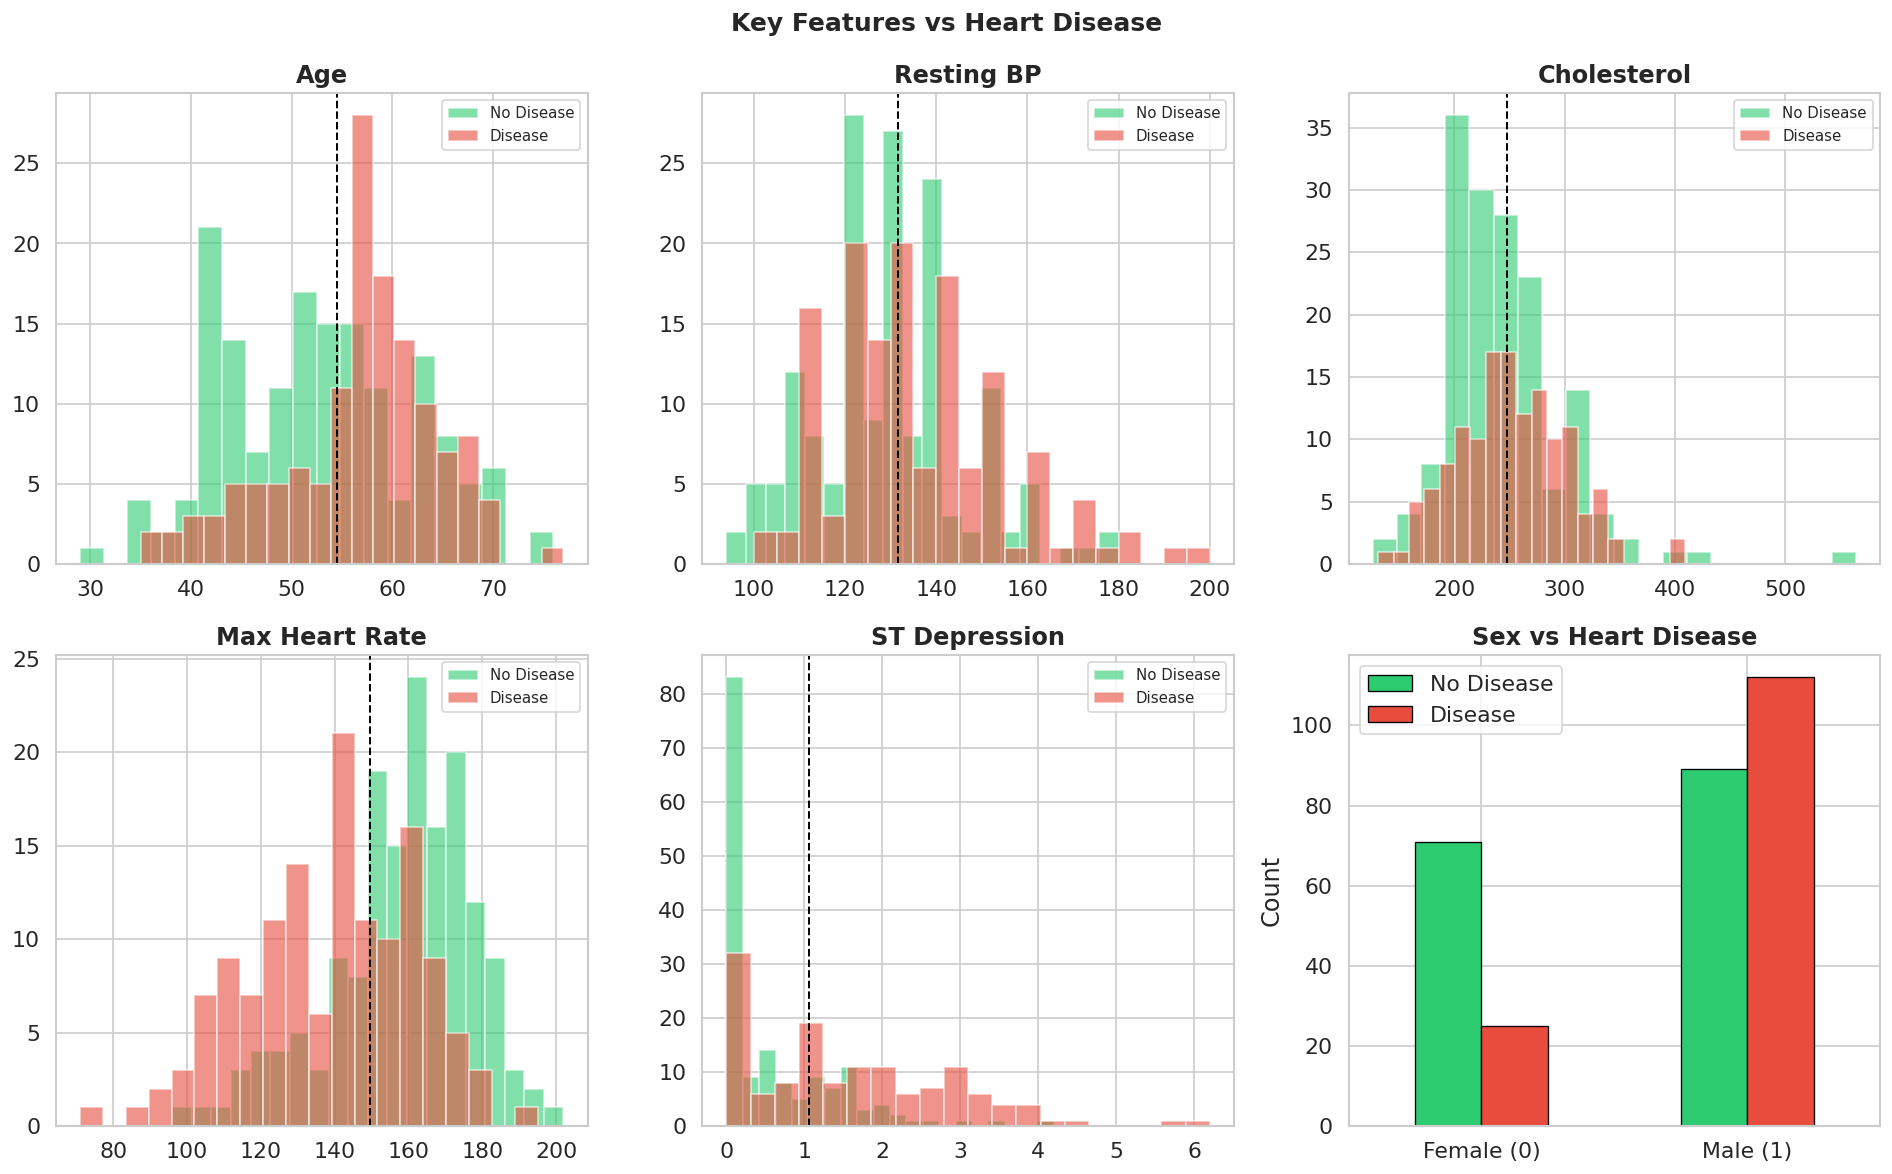

In [19]:
# ─────────────────────────────────────────
# STEP 6b: Key Features vs Heart Disease
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Features vs Heart Disease', fontsize=15, fontweight='bold')

numeric_feats = ['Age', 'Resting BP', 'Cholesterol', 'Max Heart Rate', 'ST Depression']
for ax, feat in zip(axes.flatten(), numeric_feats):
    for target_val, label, color in [(0, 'No Disease', '#2ecc71'), (1, 'Disease', '#e74c3c')]:
        subset = df[df['Target'] == target_val][feat]
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.axvline(df[feat].mean(), color='black', linestyle='--', linewidth=1.2)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)

# Sex breakdown
sex_target = df.groupby(['Sex', 'Target']).size().unstack()
sex_target.index = ['Female (0)', 'Male (1)']
sex_target.columns = ['No Disease', 'Disease']
sex_target.plot(kind='bar', ax=axes[1][2], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.8, rot=0)
axes[1][2].set_title('Sex vs Heart Disease', fontweight='bold')
axes[1][2].set_ylabel('Count')
axes[1][2].legend()

plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()

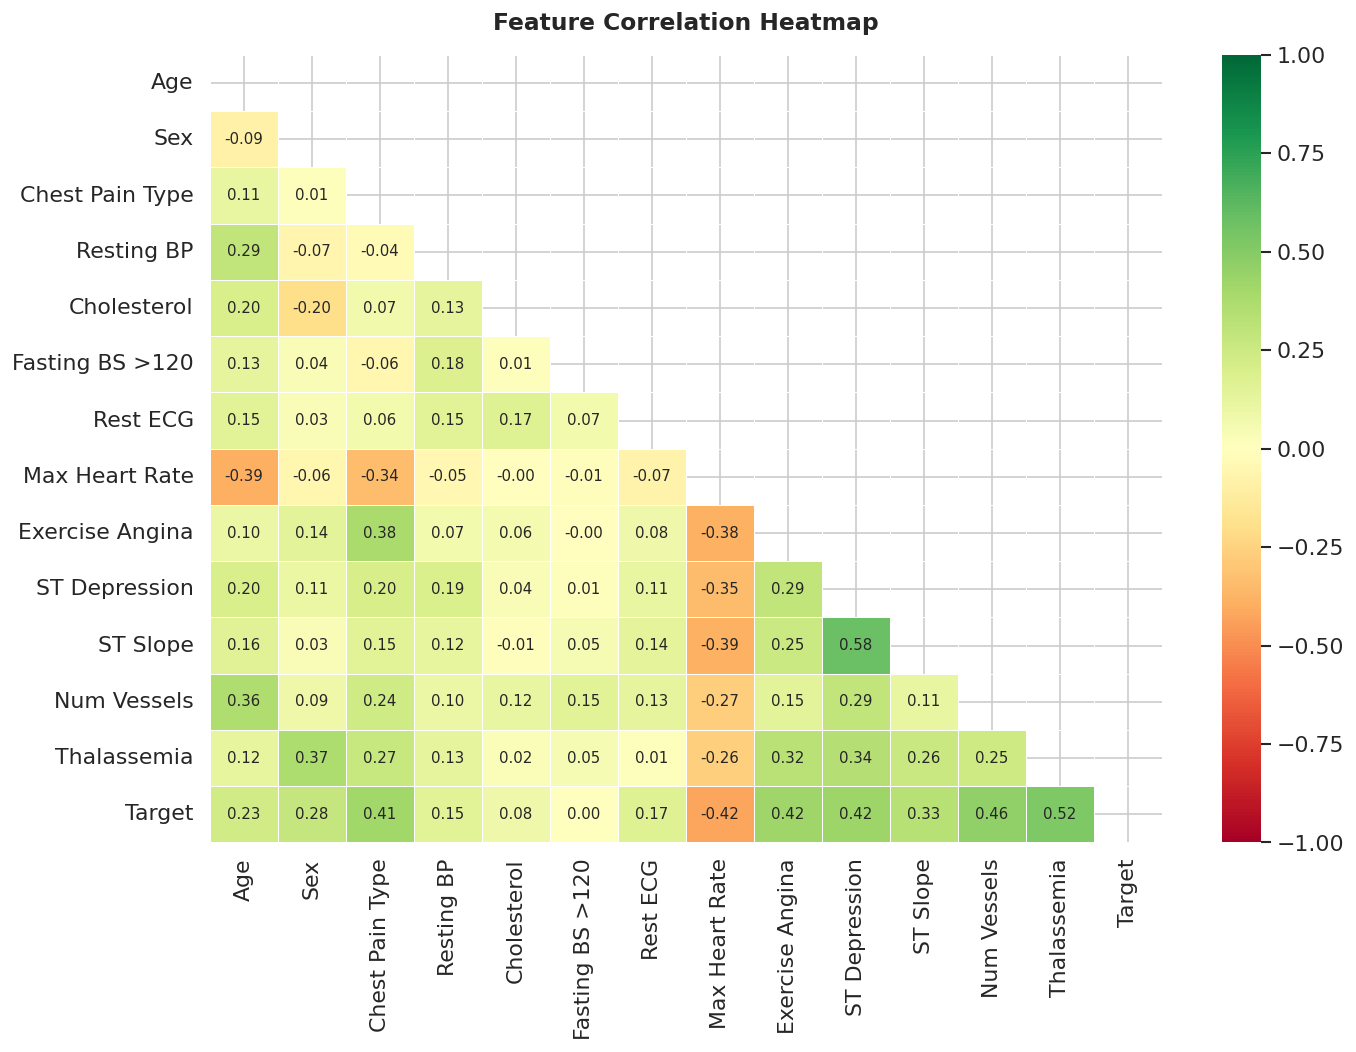

In [20]:
# ─────────────────────────────────────────
# STEP 6c: Correlation Heatmap
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            ax=ax, linewidths=0.5, annot_kws={'size': 9},
            vmin=-1, vmax=1, center=0)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 Model Training

In [21]:
# ─────────────────────────────────────────
# STEP 7: Train/Test Split & Scale
# ─────────────────────────────────────────
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Train: {len(X_train)} | Test: {len(X_test)}')
print(f'   Train class balance: {y_train.value_counts().to_dict()}')
print(f'   Test  class balance: {y_test.value_counts().to_dict()}')

✅ Train: 237 | Test: 60
   Train class balance: {0: 128, 1: 109}
   Test  class balance: {0: 32, 1: 28}


In [22]:
# ─────────────────────────────────────────
# STEP 8: Train Models & Evaluate
# ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   min_samples_leaf=3, random_state=42)
}

results = {}
probs   = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    prob  = model.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, prob)
    cv  = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc').mean()

    results[name] = {'Accuracy': round(acc*100, 2), 'ROC-AUC': round(roc, 4), 'CV ROC-AUC': round(cv, 4)}
    probs[name]   = prob

    print(f'✅ {name}: Acc={acc*100:.1f}% | ROC-AUC={roc:.4f} | CV-AUC={cv:.4f}')

print('\n📌 Summary:')
display(pd.DataFrame(results).T)

✅ Logistic Regression: Acc=91.7% | ROC-AUC=0.9531 | CV-AUC=0.8873
✅ Decision Tree: Acc=78.3% | ROC-AUC=0.8265 | CV-AUC=0.7933
✅ Random Forest: Acc=85.0% | ROC-AUC=0.9442 | CV-AUC=0.8859

📌 Summary:


,Accuracy,ROC-AUC,CV ROC-AUC
Logistic Regression,91.67,0.9531,0.8873
Decision Tree,78.33,0.8265,0.7933
Random Forest,85.00,0.9442,0.8859


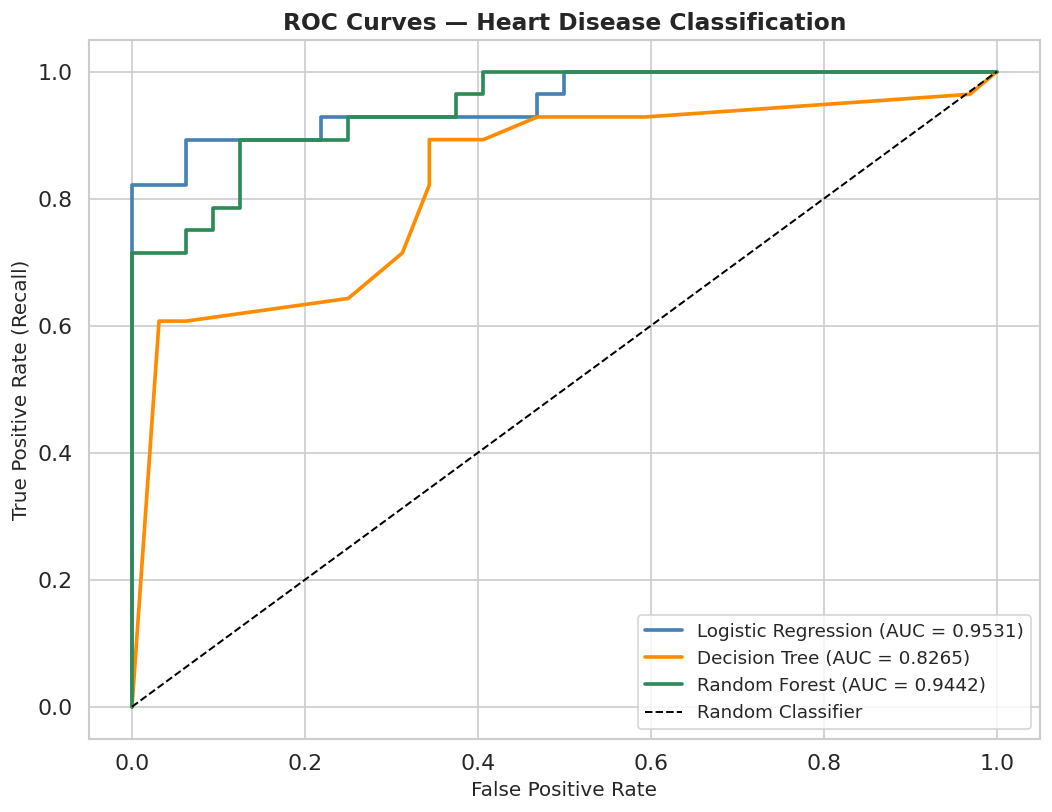

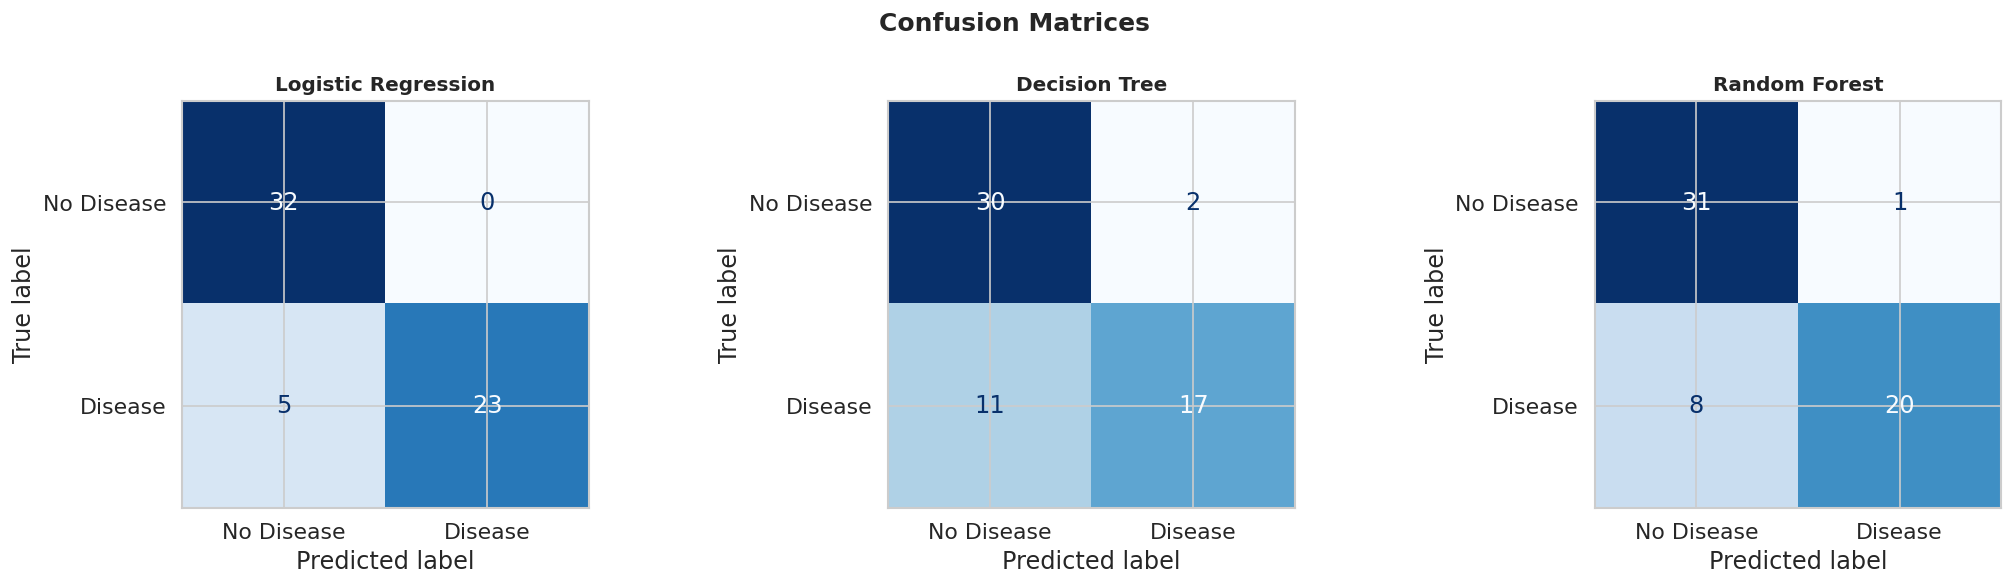


📌 Classification Report — Logistic Regression (Best Model):
              precision    recall  f1-score   support

  No Disease       0.86      1.00      0.93        32
     Disease       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



In [23]:
# ─────────────────────────────────────────
# STEP 9 & 10: ROC Curves + Confusion Matrices
# ─────────────────────────────────────────

# ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['steelblue', 'darkorange', 'seagreen']

for (name, prob), color in zip(probs.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'{name} (AUC = {auc})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier')
ax.set_title('ROC Curves — Heart Disease Classification', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test_sc)
    cm    = confusion_matrix(y_test, preds)
    disp  = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

best_name  = max(results, key=lambda k: results[k]['ROC-AUC'])
best_preds = models[best_name].predict(X_test_sc)
print(f'\n📌 Classification Report — {best_name} (Best Model):')
print(classification_report(y_test, best_preds, target_names=['No Disease', 'Disease']))

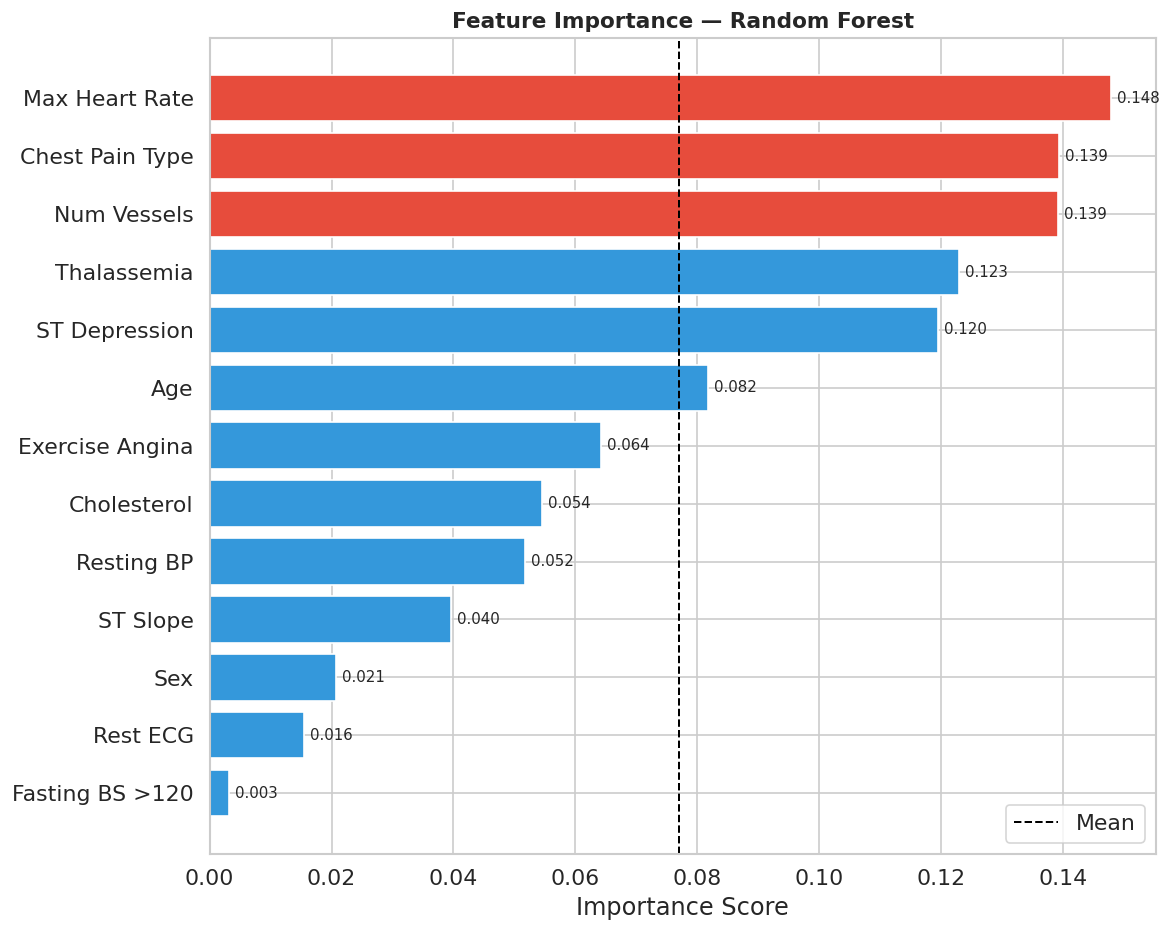

In [25]:
# ─────────────────────────────────────────
# STEP 11 & 12: Feature Importance + Key Findings
# ─────────────────────────────────────────
rf_model    = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

colors_bar = ['#e74c3c' if v > importances.quantile(0.75) else '#3498db' for v in importances.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances.index, importances.values, color=colors_bar, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importances.mean(), color='black', linestyle='--', linewidth=1.2, label='Mean')
ax.legend()
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 📝 Key Findings

In [26]:
# Key Findings
best_acc  = results[best_name]['Accuracy']
best_auc  = results[best_name]['ROC-AUC']
top_feat  = importances.sort_values(ascending=False).index[0]

print(f"""
╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — HEART DISEASE PREDICTION          ║
╠══════════════════════════════════════════════════════════╣
║ Best Model  : {best_name:<41}║
║ Accuracy    : {best_acc}%{' '*(40-len(str(best_acc)))}║
║ ROC-AUC     : {best_auc:<41}║
║ Top Feature : {top_feat:<41}║
╠══════════════════════════════════════════════════════════╣
║ • Max Heart Rate & ST Depression are top predictors      ║
║ • Males show higher disease prevalence                   ║
║ • Chest Pain Type is strongly correlated with Target     ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — HEART DISEASE PREDICTION          ║
╠══════════════════════════════════════════════════════════╣
║ Best Model  : Logistic Regression                      ║
║ Accuracy    : 91.67%                                   ║
║ ROC-AUC     : 0.9531                                   ║
║ Top Feature : Max Heart Rate                           ║
╠══════════════════════════════════════════════════════════╣
║ • Max Heart Rate & ST Depression are top predictors      ║
║ • Males show higher disease prevalence                   ║
║ • Chest Pain Type is strongly correlated with Target     ║
╚══════════════════════════════════════════════════════════╝

